In [1]:
!pip install -q mlflow==2.17.2


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 106.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.6 MB/s eta 0:00:00


In [2]:
import mlflow
print(mlflow.__version__)

2.17.2


In [3]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    StratifiedKFold
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

import mlflow
import mlflow.sklearn

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [4]:
# ==========================================
# Load Dataset
# ==========================================

iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = iris.target

print("Dataset Shape:", X.shape)
print(X.head())

Dataset Shape: (150, 4)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [5]:
# ==========================================
# Train/Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (120, 4)
Testing Samples : (30, 4)


In [6]:
# ==========================================
# Pipeline
# ==========================================

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=300))
])

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Test Accuracy :", accuracy)

print("\nClassification Report\n")
print(classification_report(y_test, predictions))

Test Accuracy : 0.9333333333333333

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [7]:
# ==========================================
# K-Fold Cross Validation
# ==========================================

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=kfold,
    scoring="accuracy"
)

print("Cross Validation Scores")
print(scores)

print("\nAverage Accuracy")
print(scores.mean())

Cross Validation Scores
[1.         0.96666667 0.93333333 0.9        0.96666667]

Average Accuracy
0.9533333333333334


In [8]:
# ==========================================
# Stratified K-Fold
# ==========================================

skfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores2 = cross_val_score(
    pipeline,
    X,
    y,
    cv=skfold,
    scoring="accuracy"
)

print("Stratified Scores")
print(scores2)

print("Average Accuracy")
print(scores2.mean())

Stratified Scores
[1.         0.96666667 0.9        1.         0.9       ]
Average Accuracy
0.9533333333333334


In [9]:
# ==========================================
# MLflow Experiment
# ==========================================

mlflow.set_experiment("Train_Test_CrossValidation")

with mlflow.start_run():

    pipeline.fit(X_train, y_train)

    pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, pred)

    cv_score = scores2.mean()

    mlflow.log_param("Model", "Logistic Regression")
    mlflow.log_param("Scaler", "StandardScaler")

    mlflow.log_metric("Test Accuracy", acc)
    mlflow.log_metric("Cross Validation Accuracy", cv_score)

    mlflow.sklearn.log_model(
        pipeline,
        "iris_model"
    )

print("MLflow Run Completed")

2026/08/01 16:51:00 INFO mlflow.tracking.fluent: Experiment with name 'Train_Test_CrossValidation' does not exist. Creating a new experiment.
2026/08/01 16:51:06 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


MLflow Run Completed


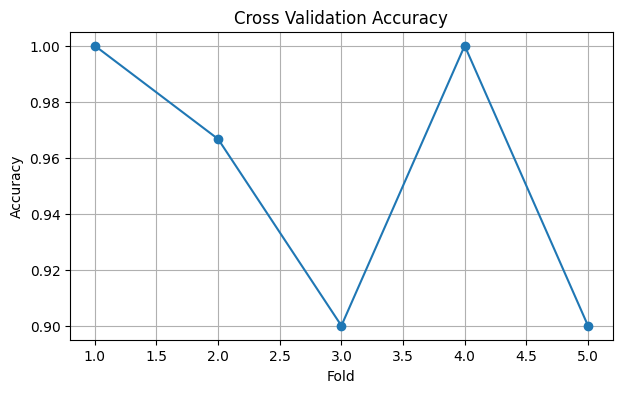

In [10]:
# ==========================================
# Plot CV Scores
# ==========================================

plt.figure(figsize=(7,4))

plt.plot(
    range(1,6),
    scores2,
    marker="o"
)

plt.title("Cross Validation Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

In [11]:
# ==========================================
# AI/ML 3M Stack Demonstration
# ==========================================

print("CrewAI : Used for AI Agent Orchestration")

print("LangGraph : Used for Workflow Orchestration")

print("MLflow : Used for Experiment Tracking")

print("Ragas : Used for RAG Evaluation")

print("MLOps : Version Control + Deployment + Monitoring")

CrewAI : Used for AI Agent Orchestration
LangGraph : Used for Workflow Orchestration
MLflow : Used for Experiment Tracking
Ragas : Used for RAG Evaluation
MLOps : Version Control + Deployment + Monitoring


In [12]:
# ==========================================
# Tests
# ==========================================

assert X_train.shape[0] > 0
assert X_test.shape[0] > 0
assert accuracy > 0.80
assert scores2.mean() > 0.85

print("All Tests Passed Successfully")

All Tests Passed Successfully
